In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rsatoolbox as rsa
import os
import globals as gl

plt.style.use('default')


Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


Text(0.5, 0.98, 'participant:103, hemisphere:L')

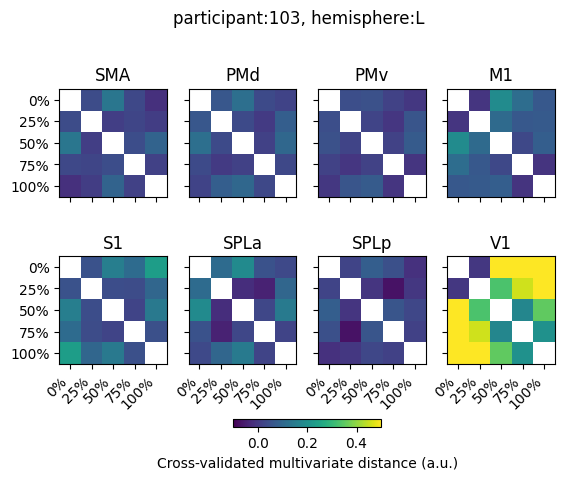

In [8]:
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
experiment = 'smp2'
vmin, vmax = -.1, .5
sn=103
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True)

for r, roi in enumerate(rois):

    row = r // 4
    col = r % 4
    rdms = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
    rdms = rdms.subset_pattern(by='conds', value=['0%', '25%', '50%', '75%', '100%'])

    cax = rsa.vis.show_rdm_panel(
            rdms, axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)

    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'participant:{sn}, hemisphere:{Hem}')
